<a href="https://colab.research.google.com/github/dherreraal/data_structures/blob/main/Clase_09/09_ED_BST_Insert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Árbol Completo Infijo y BST Insert
### Universidad Nacional de Colombia
#### **Profesor:** David Alberto Herrera Alvarez
#### **Curso:** Estructuras de Datos
---

## Índice de Contenido
1. Motivación: Limitaciones de Estructuras Anteriores
2. Propiedades Clave de los BST (Repaso)
3. Operaciones de Búsqueda: `Find(k)` y Rango
4. Elemento Siguiente: `Next(N)`
5. Inserción en un BST: `Insert(k)`
6. Árbol Completo Infijo (Infix Expression Tree)
7. Ejercicios Prácticos
8. Bibliografía y Referencias
---

## 1. Motivación: Limitaciones de Estructuras Anteriores

¿Por qué necesitamos Árboles Binarios de Búsqueda (BST)? Evaluemos cómo se comportan otras estructuras que ya conocemos ante ciertas operaciones requeridas para **búsquedas locales** (Local Search) como `RangeSearch(x, y)` (encontrar elementos en un rango) y `NearestNeighbors(z)` (encontrar el elemento más cercano):

* **Hash Tables (Tablas Hash):**
  * Insertar / Eliminar: **$O(1)$** ✅
  * Búsqueda Exacta: **$O(1)$** ✅
  * `RangeSearch` / `NearestNeighbors`: **¡Imposible!** ❌ (Los elementos no guardan relación de orden).

* **Array Desordenado o Linked List:**
  * Insertar: **$O(1)$** ✅
  * Búsqueda / RangeSearch / NearestNeighbors: **$O(n)$** ❌ (Demasiado lento).

* **Sorted Array (Arreglo Ordenado):**
  * Búsqueda / RangeSearch / NearestNeighbors: **$O(\log n)$** ✅ (Usando búsqueda binaria).
  * Insertar / Eliminar: **$O(n)$** ❌ (Hay que desplazar todos los elementos subsecuentes).

**Conclusión:** Necesitamos una estructura que ofrezca búsquedas en **$O(\log n)$** (como el arreglo ordenado) pero que permita inserciones y eliminaciones rápidas sin desplazar elementos. ¡Esa estructura es el **Search Tree**!


## 2. Propiedades Clave de los BST (Repaso)

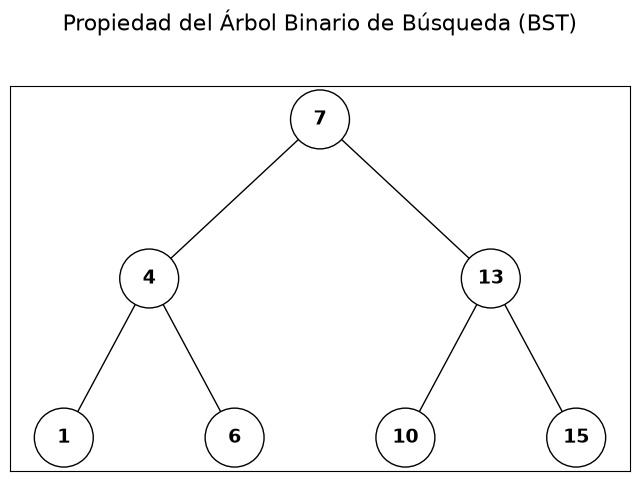

**Propiedad fundamental del Search Tree:**
Para cualquier nodo $X$, su clave (key) es **mayor** que la clave de cualquier descendiente en su subárbol izquierdo, y **menor** que la clave de cualquier descendiente en su subárbol derecho.


## 3. Operaciones de Búsqueda: `Find(k)` y Rango

Dado un nodo raíz $R$ y una clave $k$, queremos retornar el nodo que contenga $k$. Gracias a la propiedad del BST, no tenemos que buscar en todo el árbol, basta con tomar un camino descendente:

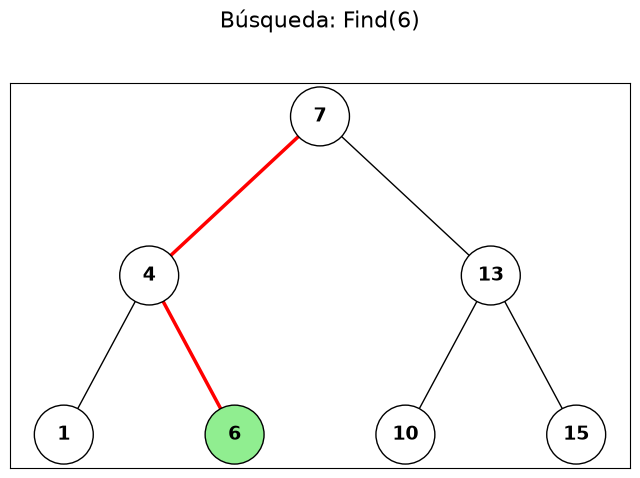

**Algoritmo `Find(k, R)`:**
```java
if (R == null) return null;
if (R.key == k) return R;
if (R.key > k)
    return Find(k, R.left);
else
    return Find(k, R.right);
```

**Búsqueda en Rango `RangeSearch(x, y)`:**
Para encontrar todos los nodos entre $x$ e $y$, podemos empezar con `N = Find(x, R)` y luego llamar repetidamente a `Next(N)` (sucesor) hasta que la clave supere a $y$.


## 4. Elemento Siguiente: `Next(N)`

Dada la posición de un nodo $N$, ¿cómo encontramos el siguiente nodo más grande (su sucesor en orden)?

Tenemos dos casos:
1. **El nodo tiene hijo derecho:** El siguiente elemento es el descendiente más a la izquierda de su hijo derecho. `LeftDescendant(N.right)`
2. **El nodo NO tiene hijo derecho:** Debemos subir por el árbol hacia los padres hasta encontrar un nodo del cual seamos descendientes por la izquierda. `RightAncestor(N)`

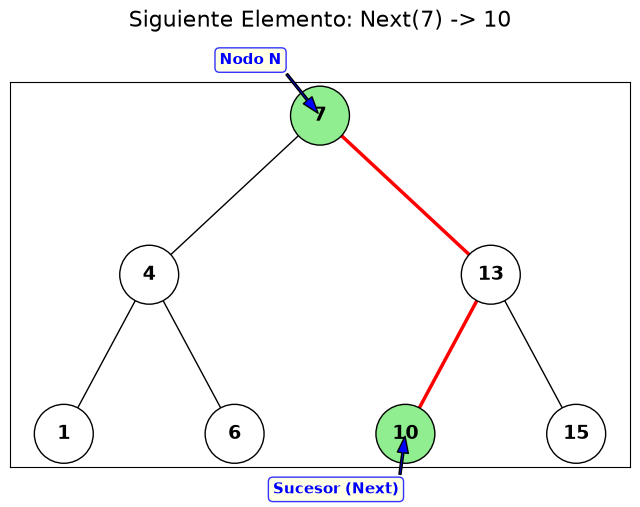


## 5. Inserción en un BST: `Insert(k)`

Insertar un elemento es muy sencillo si aprovechamos la lógica de `Find`.

1. Buscamos la clave $k$ en el árbol.
2. Si no la encontramos, la búsqueda terminará en un puntero `null`. ¡Ese es el lugar exacto donde debería ir $k$!
3. Colocamos el nuevo nodo como hijo de la última hoja visitada.

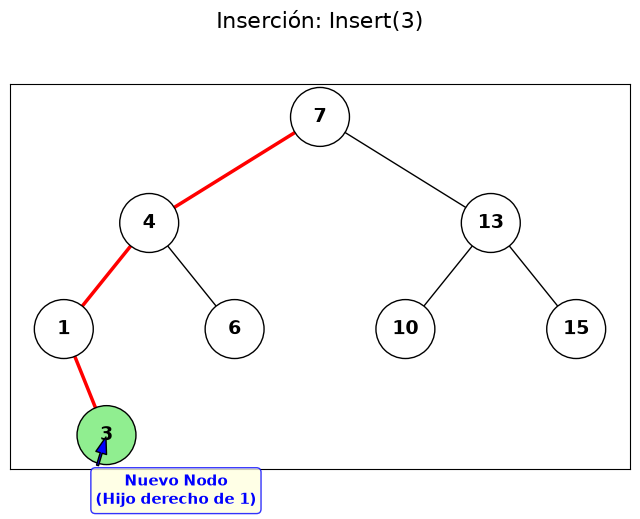

> 💡 **Recurso Interactivo:** Para visualizar y manipular en tiempo real cómo se insertan y ordenan los nodos en un BST, te recomendamos usar el **[Data Structure Visualizer de la Universidad de San Francisco (USFCA)](https://www.cs.usfca.edu/~galles/visualization/BST.html)**. ¡Es una herramienta excelente para ver la estructura en acción!


## 6. Árbol Completo Infijo (Infix Expression Tree)

Un uso muy común de la estructura de árboles binarios es el modelado de operaciones algebraicas. Esto genera un **Árbol Completo** (o Árbol Lleno).

Cuando hacemos un recorrido **In-Order** (Izquierda - Padre - Derecha) sobre un árbol sintáctico, obtenemos la expresión en formato **Infijo** (la forma en la que los humanos escribimos matemáticas comúnmente, p. ej. `(5 - 3) * (6 + 2)`).

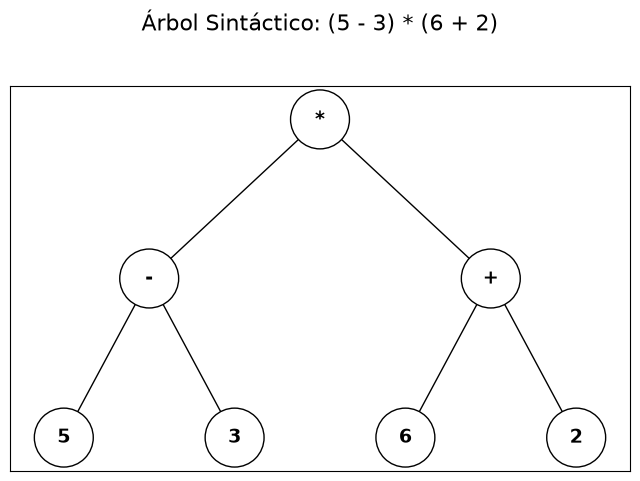
<br><em>Figura 5: Árbol sintáctico de la expresión (5 - 3) * (6 + 2). Un recorrido In-Order reconstruye la expresión original.</em>

Añadiendo paréntesis al inicio y al final de cada subárbol, garantizamos que se respete la precedencia de las operaciones.


## 7. Ejercicios Prácticos

### Ejercicio 1: Inserción Iterativa en un BST
Implementa el algoritmo de inserción para un BST de manera iterativa (usando un bucle `while` en lugar de recursividad).


In [ ]:
%%writefile BSTInsertIterative.java
class Node {
    int key;
    Node left, right;
    public Node(int item) { key = item; left = right = null; }
}

public class BSTInsertIterative {
    Node root;

    public void insert(int key) {
        Node newNode = new Node(key);
        if (root == null) {
            root = newNode;
            return;
        }

        Node current = root;
        Node parent = null;

        while (true) {
            parent = current;

            // TODO: Completa la lógica de inserción iterativa
            // Si key es menor que current.key, ir a la izquierda. Si es mayor, ir a la derecha.
            // Si current se vuelve null, inserta el newNode como hijo del parent.
            if (key < current.key) {
                current = current.left;
                if (current == null) {
                    parent.left = newNode;
                    return;
                }
            } else {
                // TU CÓDIGO AQUÍ (Ir a la derecha)

            }
        }
    }

    public void inorder(Node n) {
        if (n != null) {
            inorder(n.left);
            System.out.print(n.key + " ");
            inorder(n.right);
        }
    }

    public static void main(String[] args) {
        BSTInsertIterative tree = new BSTInsertIterative();
        int[] vals = {50, 30, 20, 40, 70, 60, 80};
        for(int v : vals) tree.insert(v);

        System.out.print("Arbol ordenado (InOrder): ");
        tree.inorder(tree.root); // Debería imprimir: 20 30 40 50 60 70 80
        System.out.println();
    }
}


In [ ]:
!javac BSTInsertIterative.java
!java BSTInsertIterative


### Ejercicio 2: Imprimir Expresión Infija con Paréntesis
Dado un Árbol Sintáctico donde los nodos internos son operadores (`+`, `-`, `*`, `/`) y las hojas son operandos, imprime la ecuación en notación **Infija** agregando paréntesis para mantener la jerarquía de las operaciones. Corresponde a la *Figura 5*.


In [ ]:
%%writefile InfixTree.java
class TreeNode {
    String val;
    TreeNode left, right;
    public TreeNode(String x) { val = x; left = right = null; }
}

public class InfixTree {

    // TODO: Implementar el recorrido In-Order imprimiendo paréntesis
    public static void printInfix(TreeNode root) {
        // Tu código aquí
        // Pista: Si el nodo no es una hoja, imprime "(" antes de procesar el subárbol izquierdo.
        // Luego imprime el valor del nodo.
        // Finalmente procesa el derecho y cierra con ")".

    }

    public static boolean isLeaf(TreeNode n) {
        return n != null && n.left == null && n.right == null;
    }

    public static void main(String[] args) {
        // Expresión: (5 - 3) * (6 + 2)
        TreeNode root = new TreeNode("*");
        root.left = new TreeNode("-");
        root.right = new TreeNode("+");
        root.left.left = new TreeNode("5");
        root.left.right = new TreeNode("3");
        root.right.left = new TreeNode("6");
        root.right.right = new TreeNode("2");

        System.out.print("Ecuación Infija: ");
        printInfix(root);
        System.out.println();
        // Salida esperada: ((5 - 3) * (6 + 2))
    }
}


In [ ]:
!javac InfixTree.java
!java InfixTree


### Ejercicio 3: Validar un BST (isBST)
Es fácil decir que "los menores van a la izquierda", pero en código puede ser un poco engañoso, ya que todo el subárbol izquierdo debe ser menor al nodo raíz, no solo el hijo directo. Escribe una función recursiva para validar esto.


In [ ]:
%%writefile EjercicioIsBST.java
class Node {
    int key;
    Node left, right;
    public Node(int item) { key = item; left = right = null; }
}

public class EjercicioIsBST {
    // TODO: Implementar recursivamente la validación
    public static boolean isBST(Node root, Integer min, Integer max) {
        // Tu código aquí
        // 1. Caso base: si root es null, retorna true.
        // 2. Si el valor del nodo no está en los límites (min, max), retorna false.
        // 3. Valida el subárbol izquierdo y el subárbol derecho actualizando los límites.
        return true;
    }

    public static void main(String[] args) {
        Node root1 = new Node(10);
        root1.left = new Node(5);
        root1.right = new Node(15);
        // Correcto: 5 < 10 < 15

        Node root2 = new Node(10);
        root2.left = new Node(5);
        root2.right = new Node(15);
        root2.left.right = new Node(12); // ERROR! 12 está a la izq de 10, pero es mayor que 10.

        System.out.println("Árbol 1 es BST: " + isBST(root1, null, null)); // Esperado: true
        System.out.println("Árbol 2 es BST: " + isBST(root2, null, null)); // Esperado: false
    }
}


In [ ]:
!javac EjercicioIsBST.java
!java EjercicioIsBST


### Ejercicio 4: Range Search
Construye una función que, dados dos valores `x` y `y`, busque eficientemente todos los nodos que se encuentren en el rango de `[x, y]` y los agregue a una lista.


In [ ]:
%%writefile EjercicioRangeSearch.java
import java.util.ArrayList;
import java.util.List;

class Node {
    int key;
    Node left, right;
    public Node(int item) { key = item; left = right = null; }
}

public class EjercicioRangeSearch {

    // TODO: Buscar todos los valores en el rango [x, y]
    public static void rangeSearch(Node root, int x, int y, List<Integer> result) {
        // Tu código aquí
        // 1. Si root es null, retorna.
        // 2. Si root.key es mayor que x, busca en el subárbol izquierdo.
        // 3. Si root.key está entre x e y, agrégalo al result.
        // 4. Si root.key es menor que y, busca en el subárbol derecho.
    }

    public static void main(String[] args) {
        Node root = new Node(10);
        root.left = new Node(5);
        root.right = new Node(15);
        root.left.left = new Node(2);
        root.left.right = new Node(7);
        root.right.left = new Node(12);
        root.right.right = new Node(20);

        List<Integer> result = new ArrayList<>();
        rangeSearch(root, 6, 14, result);

        System.out.println("Valores entre 6 y 14: " + result);
        // Esperado: [7, 10, 12] (El orden variará según el recorrido que uses)
    }
}


In [ ]:
!javac EjercicioRangeSearch.java
!java EjercicioRangeSearch


### Ejercicio 5: Construir un BST Balanceado desde un Arreglo (Pre-AVL)
Como verás en clase, si insertas un arreglo ya ordenado secuencialmente en un BST, obtendrás una línea recta, que es lo mismo que una Linked List ($O(n)$).
Para evitar esto (y antes de llegar a usar Árboles AVL), una forma es tomar el elemento del **medio** del arreglo como raíz, y enviar la mitad izquierda del arreglo al subárbol izquierdo, y la mitad derecha al subárbol derecho recursivamente. ¡Inténtalo!


In [ ]:
%%writefile EjercicioBalancedBST.java
class Node {
    int key;
    Node left, right;
    public Node(int item) { key = item; left = right = null; }
}

public class EjercicioBalancedBST {

    // TODO: Construye un BST balanceado dividiendo el arreglo por la mitad
    public static Node sortedArrayToBST(int[] arr, int start, int end) {
        // Tu código aquí
        // 1. Caso base: si start > end, retorna null
        // 2. Encuentra el elemento del medio (mid) y hazlo la raíz
        // 3. Construye el subárbol izquierdo recursivamente
        // 4. Construye el subárbol derecho recursivamente
        return null;
    }

    public static void preOrder(Node node) {
        if (node == null) return;
        System.out.print(node.key + " ");
        preOrder(node.left);
        preOrder(node.right);
    }

    public static void main(String[] args) {
        int arr[] = new int[]{1, 3, 4, 6, 7, 10, 13, 15};
        Node root = sortedArrayToBST(arr, 0, arr.length - 1);

        System.out.println("Recorrido Pre-Order del BST balanceado:");
        preOrder(root);
        System.out.println();
    }
}


In [ ]:
!javac EjercicioBalancedBST.java
!java EjercicioBalancedBST


## 8. Bibliografía y Referencias
1. Rhodes, N. *Binary Search Trees: Introduction*.
2. Rhodes, N. *Binary Search Trees: Search Trees*.
3. Rhodes, N. *Binary Search Trees: Basic Operations*.
4. **[USFCA Data Structure Visualizer - BST](https://www.cs.usfca.edu/~galles/visualization/BST.html)**

